# Population

This short how-to guides you through the steps to create a timeseries of the population using Global Human Settlement (GHS) Population data and save it as a csv file. The final csv file can be used as, e.g., exposure data for the drought risk estimation.

You can use two datasets from the GHS project:
- **GHS-POP**: Historical and projected population (1975-2030), see more here: [GHS Population Grid](https://human-settlement.emergency.copernicus.eu/ghs_pop2023.php)
- **GHS-WUP-POP**: Urban population projections (1975-2100), see more here: [GHS WUP Population](https://human-settlement.emergency.copernicus.eu/ghs_pop2023.php)



## Manual download of GHS Population data
The data is downloaded manually through the following webpage: [https://human-settlement.emergency.copernicus.eu/](https://human-settlement.emergency.copernicus.eu/). 

We download the global data for all years available, but at 30 arcsec resolution, and in the WGS84 (or EPSG: 4326) projection for easier handling of the data afterwards. The images below show the web interface to download the datasets and detail the settings used. 

Download GHS population             |  Download GHS WUP population
:-------------------------:|:-------------------------:
![Image](../img/GHS_POP_download.png "Web interface to download GHS population data.")  |  ![Image](../img/GHS_POP_WUP_download.png "Web interface to download GHS WUP population data.")

**GHS-POP (1975-2030)**: Download files named `GHS_POP_E{YYYY}_GLOBE_R2023A_4326_30ss_V1_0.tif` for years 1975, 1980, 1985, 1990, 1995, 2000, 2005, 2010, 2015, 2020, 2025, 2030.

**GHS-WUP (1975-2100)**: Download files named `GHS_WUP_POP_E{YYYY}_GLOBE_R2025A_4326_30ss_V1_0.tif` for years from 1975 to 2100 in 5-year intervals.

Once downloaded, move these files into the following subdirectory structure:
- `./data/population/GHS_POP/` for GHS-POP files
- `./data/population/GHS_WUP_POP/` for GHS-WUP files




## Load libraries and set up region

In [3]:
admin_id = "EL64"  # Example admin ID for Central Greece

# Choose dataset: 'GHS_POP' (1975-2030) or 'GHS_WUP_POP' (1975-2100)
dataset_choice = "GHS_WUP_POP"  # Change to "GHS_WUP_POP" for urban population projections

In [4]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import regionmask
from pathlib import Path
import rioxarray as rxr
import os
import re

# Set working directoy
os.chdir("/etc/ecmwf/nfs/dh2_home_a/nejk/code/drought_exposure") 
print(f"Working directory: {os.getcwd()}")

# Set up data directories
data_dir = Path("./data")
ghs_pop_dir = data_dir / "population" / "GHS_POP"
ghs_wup_dir = data_dir / "population" / "GHS_WUP_POP"

# Set directory and file pattern based on dataset choice
if dataset_choice == "GHS_POP":
    ghs_dir = ghs_pop_dir
    file_pattern = "*/GHS_POP_E*_GLOBE_R2023A_4326_30ss_V1_0.tif"
    dataset_name = "GHS-POP"
    year_range = "(1975-2030)"
elif dataset_choice == "GHS_WUP_POP":
    ghs_dir = ghs_wup_dir
    file_pattern = "*/GHS_WUP_POP_E*_GLOBE_R2025A_4326_30ss_V1_0.tif"
    dataset_name = "GHS-WUP"
    year_range = "(1975-2100)"
else:
    raise ValueError(f"Invalid dataset_choice: {dataset_choice}. Must be 'GHS_POP' or 'GHS_WUP_POP'")

print(f"\nSelected dataset: {dataset_name} {year_range}")
print(f"Data directory: {ghs_dir}")

Working directory: /etc/ecmwf/nfs/dh2_home_a/nejk/code/drought_exposure

Selected dataset: GHS-WUP (1975-2100)
Data directory: data/population/GHS_WUP_POP


## Load NUTS region shapefile and define region mask

In [5]:
# Read NUTS shapefiles
regions_dir = data_dir / 'regions'
nuts_shp = regions_dir / 'NUTS_RG_20M_2024_4326' / 'NUTS_RG_20M_2024_4326.shp'
nuts_gdf = gpd.read_file(nuts_shp)

# Select the region of interest
sel_gdf = nuts_gdf[nuts_gdf['NUTS_ID'] == admin_id]
print(f"Found {admin_id} region: {sel_gdf['NUTS_NAME'].values[0]}")
print(f"Bounding box: {sel_gdf.geometry.total_bounds}")
lon_min, lat_min, lon_max, lat_max = sel_gdf.geometry.total_bounds

# Create a regionmask from the admin region geometry
admin_mask = regionmask.from_geopandas(sel_gdf, names='NUTS_ID')

Found EL64 region: Στερεά Ελλάδα
Bounding box: [21.39637798 37.98898161 24.67199242 39.27219519]


## Read GHS population data

In [6]:
# List all GHS tif files based on selected dataset
ghs_files = sorted(list(ghs_dir.glob(file_pattern)))
print(f"Found {len(ghs_files)} {dataset_name} files:")
for f in ghs_files:
    print(f"  {f.name}")

Found 23 GHS-WUP files:
  GHS_WUP_POP_E1975_GLOBE_R2025A_4326_30ss_V1_0.tif
  GHS_WUP_POP_E1980_GLOBE_R2025A_4326_30ss_V1_0.tif
  GHS_WUP_POP_E1985_GLOBE_R2025A_4326_30ss_V1_0.tif
  GHS_WUP_POP_E1990_GLOBE_R2025A_4326_30ss_V1_0.tif
  GHS_WUP_POP_E1995_GLOBE_R2025A_4326_30ss_V1_0.tif
  GHS_WUP_POP_E2000_GLOBE_R2025A_4326_30ss_V1_0.tif
  GHS_WUP_POP_E2005_GLOBE_R2025A_4326_30ss_V1_0.tif
  GHS_WUP_POP_E2010_GLOBE_R2025A_4326_30ss_V1_0.tif
  GHS_WUP_POP_E2015_GLOBE_R2025A_4326_30ss_V1_0.tif
  GHS_WUP_POP_E2020_GLOBE_R2025A_4326_30ss_V1_0.tif
  GHS_WUP_POP_E2025_GLOBE_R2025A_4326_30ss_V1_0.tif
  GHS_WUP_POP_E2030_GLOBE_R2025A_4326_30ss_V1_0.tif
  GHS_WUP_POP_E2035_GLOBE_R2025A_4326_30ss_V1_0.tif
  GHS_WUP_POP_E2040_GLOBE_R2025A_4326_30ss_V1_0.tif
  GHS_WUP_POP_E2045_GLOBE_R2025A_4326_30ss_V1_0.tif
  GHS_WUP_POP_E2050_GLOBE_R2025A_4326_30ss_V1_0.tif
  GHS_WUP_POP_E2055_GLOBE_R2025A_4326_30ss_V1_0.tif
  GHS_WUP_POP_E2060_GLOBE_R2025A_4326_30ss_V1_0.tif
  GHS_WUP_POP_E2065_GLOBE_R2025A_4326_30

In [7]:
# Read all GHS files and extract years (clipped to region bounding box)
datasets = []
years = []

for tif_file in ghs_files:
    # Read using rioxarray
    ds = rxr.open_rasterio(tif_file)
    
    # Clip using sel() instead of rio.clip_box to avoid artifacts
    # Note: y coordinates are typically in descending order in raster data
    ds_clipped = ds.sel(
        x=slice(lon_min, lon_max),
        y=slice(lat_max, lat_min)  # Note: reversed for descending y-coords
    )
    
    # Extract year from filename (looking for pattern E{YYYY})
    year_match = re.search(r'E(\d{4})', tif_file.name)
    if year_match:
        year = int(year_match.group(1))
        years.append(year)
        print(f"Processing year: {year}")
    else:
        print(f"Warning: Could not extract year from {tif_file.name}")
        continue
    
    datasets.append(ds_clipped)

# Sort datasets and years together by year
sorted_pairs = sorted(zip(years, datasets), key=lambda x: x[0])
years, datasets = zip(*sorted_pairs)

# Concatenate along new time dimension
pop_ds = xr.concat(datasets, dim="time")
pop_ds = pop_ds.rename("population")
pop_ds = pop_ds.squeeze("band", drop=True)

# Assign time based on extracted years
pop_ds["time"] = pd.to_datetime([f"{year}-01-01" for year in years])
pop_ds = pop_ds.assign_coords(time=pop_ds.time)

# Replace potential fill values with NaN (common fill values: -200, -99999, etc.)
pop_ds = pop_ds.where(pop_ds >= 0)

print(f"\n{dataset_name} dataset shape: {pop_ds.shape}")
print(f"Years available: {years}")
print(f"Coordinate ranges: x=[{float(pop_ds.x.min()):.2f}, {float(pop_ds.x.max()):.2f}], y=[{float(pop_ds.y.min()):.2f}, {float(pop_ds.y.max()):.2f}]")
print(f"Data value range: [{float(pop_ds.min()):.2f}, {float(pop_ds.max()):.2f}]")
pop_ds

Processing year: 1975
Processing year: 1980
Processing year: 1985
Processing year: 1990
Processing year: 1995
Processing year: 2000
Processing year: 2005
Processing year: 2010
Processing year: 2015
Processing year: 2020
Processing year: 2025
Processing year: 2030
Processing year: 2035
Processing year: 2040
Processing year: 2045
Processing year: 2050
Processing year: 2055
Processing year: 2060
Processing year: 2065
Processing year: 2070
Processing year: 2075
Processing year: 2080
Processing year: 2085

GHS-WUP dataset shape: (23, 154, 393)
Years available: (1975, 1980, 1985, 1990, 1995, 2000, 2005, 2010, 2015, 2020, 2025, 2030, 2035, 2040, 2045, 2050, 2055, 2060, 2065, 2070, 2075, 2080, 2085)
Coordinate ranges: x=[21.40, 24.67], y=[38.00, 39.27]
Data value range: [0.00, 16747.41]


<xarray.DataArray 'population' (time: 23, y: 154, x: 393)> Size: 11MB
array([[[1.43130023e+00, 1.38778465e+00, 1.66621079e+01, ...,
                    nan,            nan,            nan],
        [2.78864895e+00, 5.82096672e+00, 3.24194587e+01, ...,
                    nan,            nan,            nan],
        [1.38399830e+01, 2.04870997e+01, 2.56847391e+01, ...,
                    nan,            nan,            nan],
        ...,
        [8.75138554e+00, 1.15223484e+01, 3.94494167e+00, ...,
                    nan,            nan,            nan],
        [6.10353691e+00, 2.86462137e+00, 2.31495954e+00, ...,
                    nan,            nan,            nan],
        [5.12275056e+00, 7.12401988e+00, 9.60113152e+00, ...,
                    nan, 0.00000000e+00, 0.00000000e+00]],

       [[1.44982359e+00, 1.51394478e+00, 1.85062254e+01, ...,
                    nan,            nan,            nan],
        [3.00594908e+00, 6.33491966e+00, 3.40539176e+01, ...,
                    nan,            nan,            nan],
        [1.46917138e+01, 2.15267364e+01, 2.65696466e+01, ...,
                    nan,            nan,            nan],
...
                    nan,            nan,            nan],
        [6.78106796e-01, 6.78106796e-01, 6.78106796e-01, ...,
                    nan,            nan,            nan],
        [6.96260302e-01, 8.01215821e-01, 8.50996823e-01, ...,
                    nan, 0.00000000e+00, 0.00000000e+00]],

       [[0.00000000e+00, 0.00000000e+00, 2.26292677e-01, ...,
                    nan,            nan,            nan],
        [0.00000000e+00, 1.00121425e-02, 3.26767957e-01, ...,
                    nan,            nan,            nan],
        [1.42625180e-01, 2.38859931e-01, 3.32932427e-01, ...,
                    nan,            nan,            nan],
        ...,
        [7.59897542e-01, 8.46890941e-01, 6.77498146e-01, ...,
                    nan,            nan,            nan],
        [6.77574861e-01, 6.77574861e-01, 6.77574861e-01, ...,
                    nan,            nan,            nan],
        [6.86682841e-01, 7.39119418e-01, 7.51857203e-01, ...,
                    nan, 0.00000000e+00, 0.00000000e+00]]],
      shape=(23, 154, 393))
Coordinates:
  * time         (time) datetime64[ns] 184B 1975-01-01 1980-01-01 ... 2085-01-01
  * y            (y) float64 1kB 39.27 39.26 39.25 39.25 ... 38.01 38.0 38.0
  * x            (x) float64 3kB 21.4 21.41 21.42 21.43 ... 24.65 24.66 24.67
    spatial_ref  int64 8B 0
Attributes: (12/14)
    TIFFTAG_SOFTWARE:        MATLAB 9.13, Mapping Toolbox 5.4
    AREA_OR_POINT:           Area
    STATISTICS_COUNT:        228873117.0
    STATISTICS_COVARIANCES:  59768.11209801803
    STATISTICS_MAXIMUM:      104596.36416308
    STATISTICS_MEAN:         17.786194483986
    ...                      ...
    STATISTICS_SKIPFACTORX:  1
    STATISTICS_SKIPFACTORY:  1
    STATISTICS_STDDEV:       244.47517685446
    _FillValue:              -200.0
    scale_factor:            1.0
    add_offset:              0.0

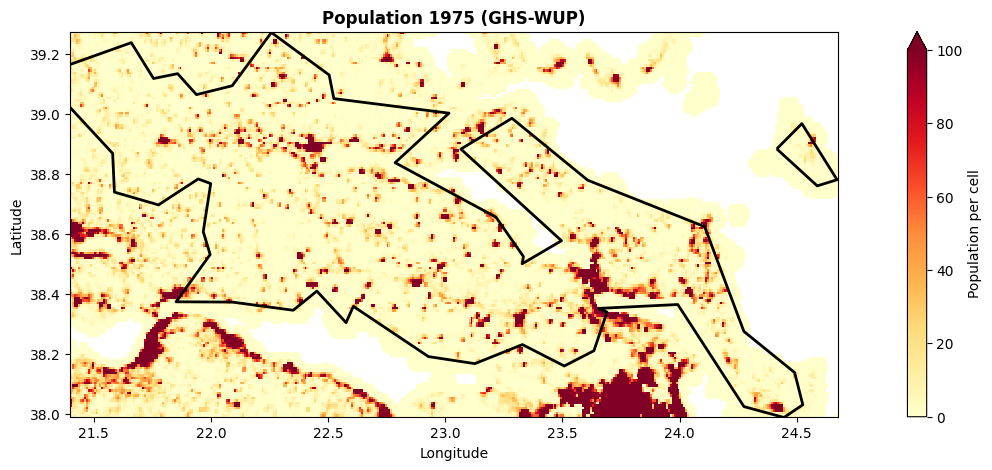

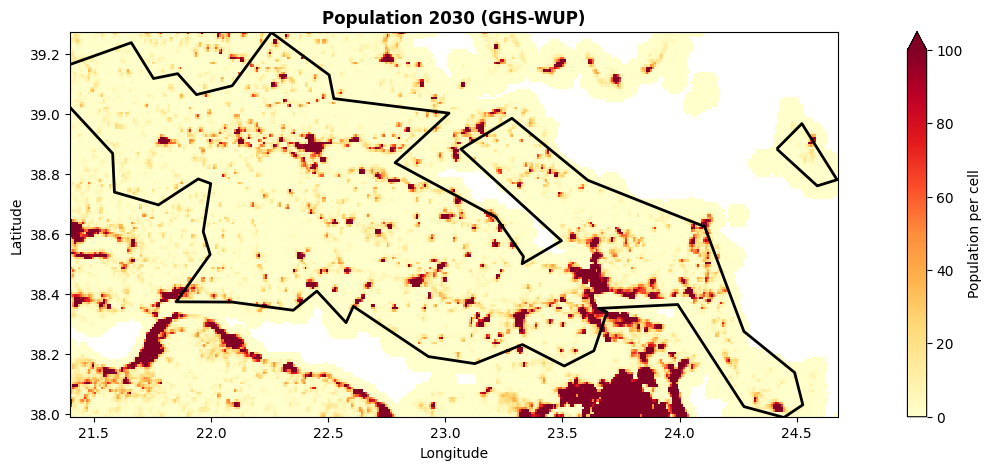

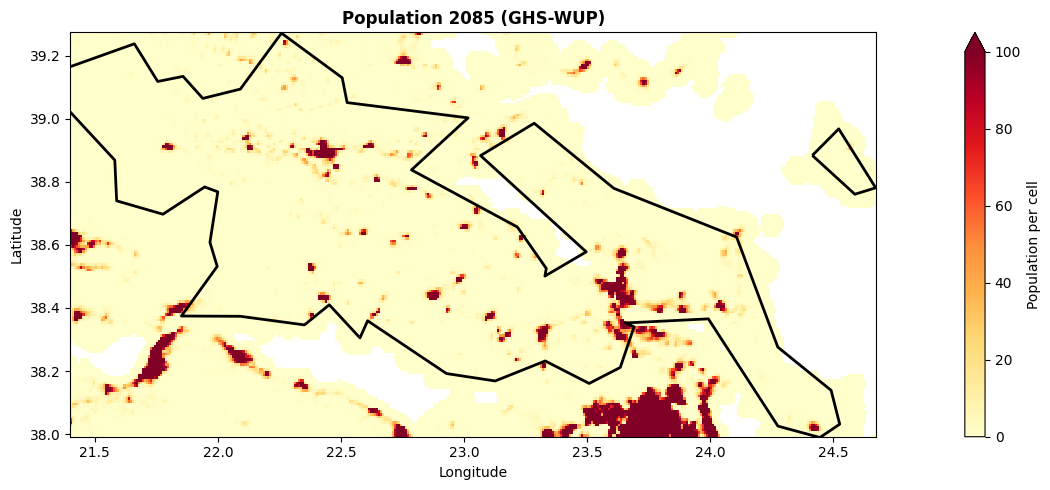

In [8]:
# Plot population for selected years
selected_years = [0, len(years)//2, -1]  # First, middle, last

for idx, time_idx in enumerate(selected_years):
    fig, axes = plt.subplots(1, 1, figsize=(18, 5))
    
    year = pop_ds.time.dt.year.values[time_idx]
    
    im = pop_ds.isel(time=time_idx).plot(
        ax=axes,
        cmap='YlOrRd',
        add_colorbar=True,
        cbar_kwargs={'label': 'Population per cell'},
        vmin=0,
        vmax=100
    )
    
    axes.set_title(f'Population {year} ({dataset_name})', fontsize=12, fontweight='bold')
    axes.set_xlabel('Longitude')
    axes.set_ylabel('Latitude')
    # Add region boundary
    sel_gdf.boundary.plot(ax=axes, color='black', linewidth=2)

plt.tight_layout()
plt.show()

## Create region masks and calculate population

In [9]:
# Data is already clipped to bounding box, so we use it directly as pop_region
pop_region = pop_ds

# Create admin region mask
pop_admin_mask_raw = admin_mask.mask(pop_region.x, pop_region.y)
pop_admin_mask = xr.DataArray(
    (~np.isnan(pop_admin_mask_raw.values)).astype(float),
    coords={'y': pop_region.y, 'x': pop_region.x},
    dims=['y', 'x']
)

print(f"{dataset_name} admin mask: {pop_admin_mask.sum().values:.0f} grid cells")

GHS-WUP admin mask: 23973 grid cells


In [10]:
# Diagnostic: Check data quality before visualization
print("Data diagnostics:")
print(f"  Population grid shape: {pop_region.shape}")
print(f"  Mask shape: {pop_admin_mask.shape}")
print(f"  Number of masked cells: {pop_admin_mask.sum().values:.0f}")
print(f"  Population data - NaN count: {pop_region.isnull().sum().values}")
print(f"  Population data - Valid values: {(~pop_region.isnull()).sum(['x', 'y']).values}")

# Check a single time slice
sample_time = 0
sample_data = pop_region.isel(time=sample_time)
print(f"\nSample year {pop_region.time.dt.year.values[sample_time]}:")
print(f"  Valid cells (not NaN): {(~sample_data.isnull()).sum().values}")
print(f"  Min value: {float(sample_data.min()):.2f}")
print(f"  Max value: {float(sample_data.max()):.2f}")
print(f"  Mean value: {float(sample_data.mean()):.2f}")

Data diagnostics:
  Population grid shape: (23, 154, 393)
  Mask shape: (154, 393)
  Number of masked cells: 23973
  Population data - NaN count: 283866
  Population data - Valid values: [48180 48180 48180 48180 48180 48180 48180 48180 48180 48180 48180 48180
 48180 48180 48180 48180 48180 48180 48180 48180 48180 48180 48180]

Sample year 1975:
  Valid cells (not NaN): 48180
  Min value: 0.00
  Max value: 15074.26
  Mean value: 54.38


## Visualize population distribution

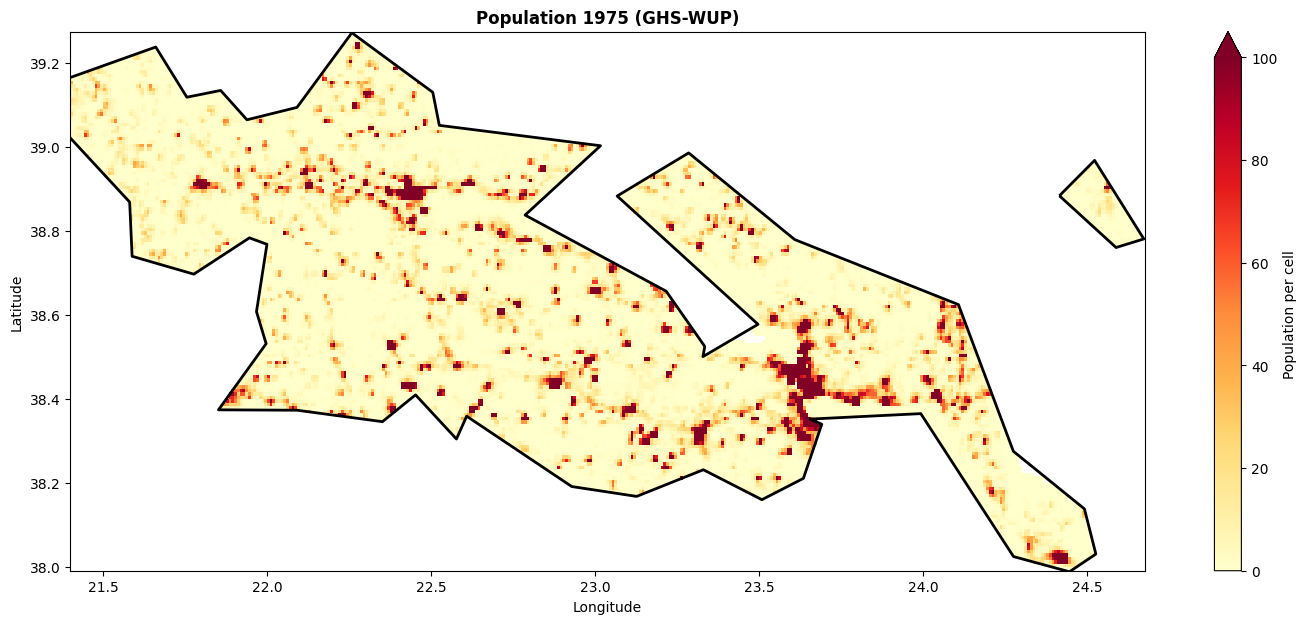

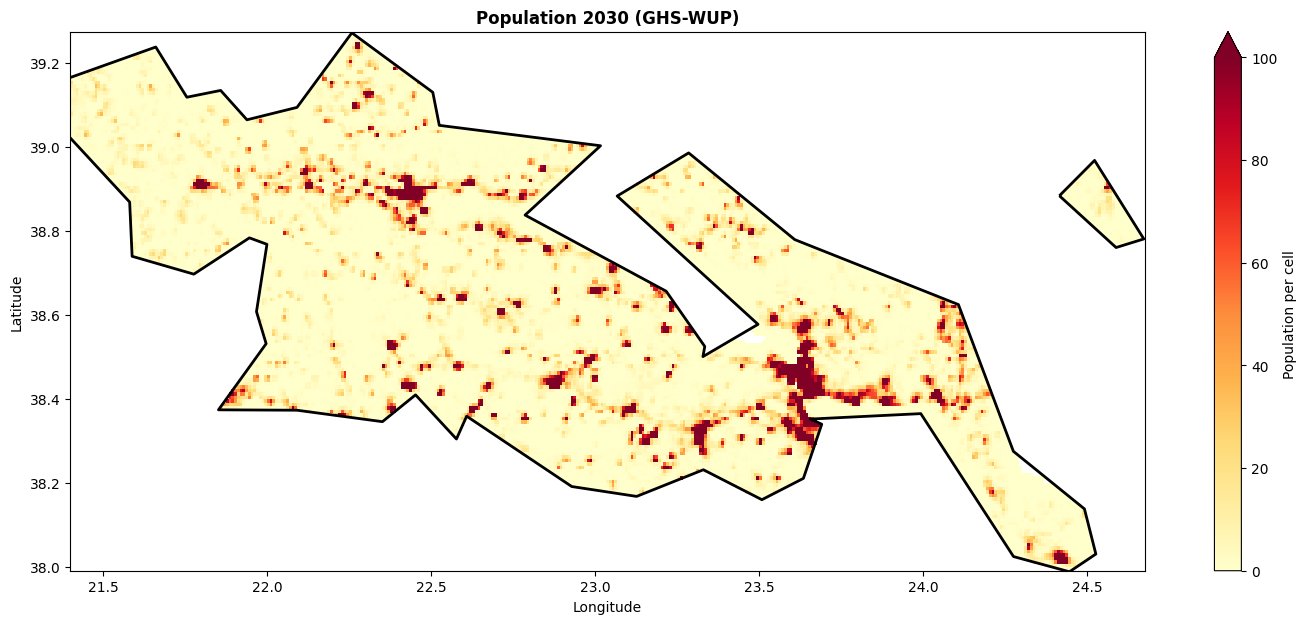

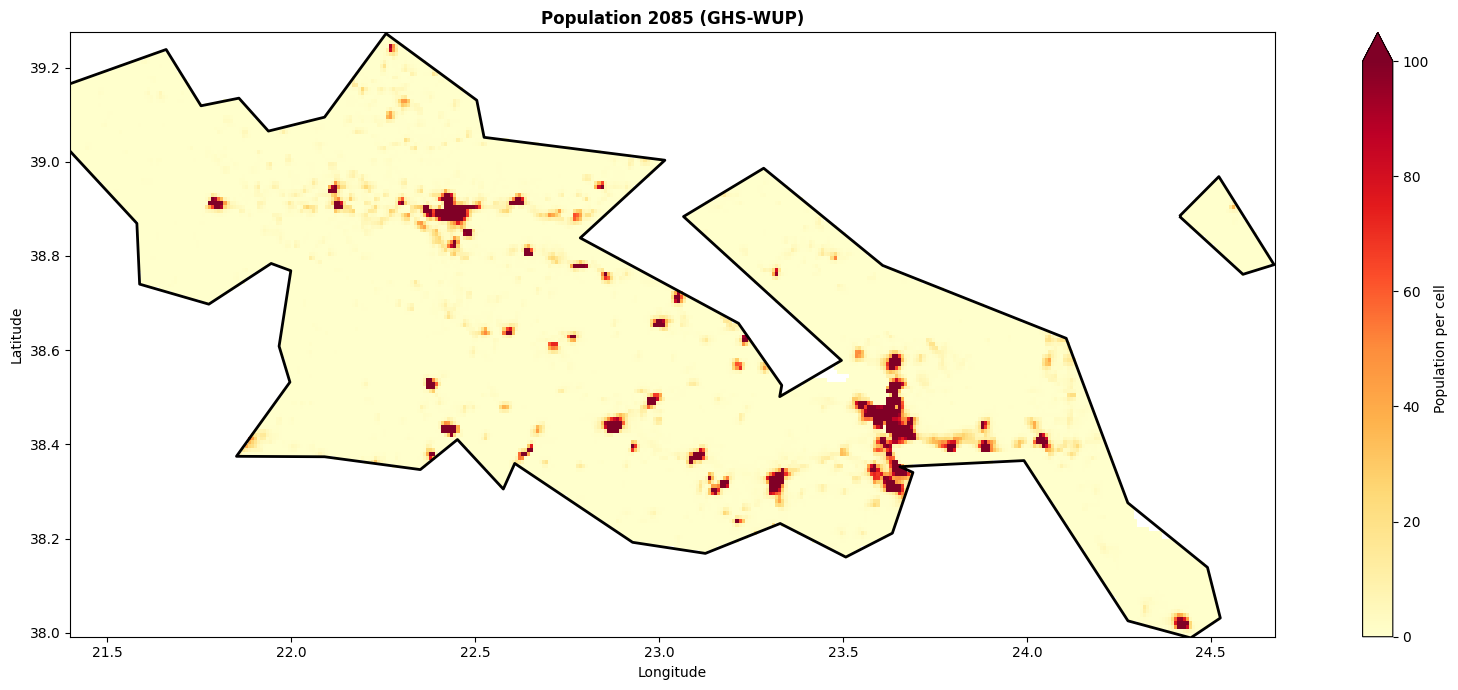

In [11]:
# Plot population for selected years
selected_years = [0, len(years)//2, -1]  # First, middle, last


for idx, time_idx in enumerate(selected_years):

    fig, axes = plt.subplots(1, 1, figsize=(18, 7))    
    year = pop_region.time.dt.year.values[time_idx]
    
    # Apply mask and plot
    masked_pop = pop_region.isel(time=time_idx).where(pop_admin_mask == 1)
    
    #im = masked_pop.plot(
    im = masked_pop.plot(
        ax=axes,
        cmap='YlOrRd',
        add_colorbar=True,
        cbar_kwargs={'label': 'Population per cell'},
        vmin=0,
        vmax=100,
    )
    
    axes.set_title(f'Population {year} ({dataset_name})', fontsize=12, fontweight='bold')
    axes.set_xlabel('Longitude')
    axes.set_ylabel('Latitude')
    # Add region boundary
    sel_gdf.boundary.plot(ax=axes, color='black', linewidth=2)

plt.tight_layout()
plt.show()

## Calculate total population for each year

We calculate the total population within the region by summing all population values within the masked area.

In [12]:
# Calculate total population for each year
pop_results = []

for i, year in enumerate(years):
    # Get data for this year
    data = pop_region.isel(time=i)
    
    # Apply mask and sum population
    masked_data = data.where(pop_admin_mask == 1, 0)
    total_pop = masked_data.sum().values
    
    pop_results.append({
        'year': year,
        'population': total_pop
    })
    
    print(f"{year}: {total_pop:,.0f} people")

df_pop = pd.DataFrame(pop_results)
print(f"\n{dataset_name} results:")
print(df_pop)

1975: 425,902 people
1980: 444,018 people
1985: 470,751 people
1990: 490,413 people
1995: 508,224 people
2000: 521,798 people
2005: 531,397 people
2010: 534,820 people
2015: 511,960 people
2020: 505,003 people
2025: 451,386 people
2030: 422,460 people
2035: 402,608 people
2040: 382,952 people
2045: 364,496 people
2050: 344,874 people
2055: 323,530 people
2060: 300,803 people
2065: 279,098 people
2070: 257,720 people
2075: 241,366 people
2080: 226,672 people
2085: 215,900 people

GHS-WUP results:
    year          population
0   1975  425902.28510579164
1   1980   444017.9732226621
2   1985   470750.8985756294
3   1990   490412.7463494472
4   1995   508224.2765996824
5   2000   521798.0971954223
6   2005   531397.3719865205
7   2010   534819.5705059934
8   2015  511959.95214792923
9   2020    505002.546691046
10  2025   451385.5023026058
11  2030  422459.64027757756
12  2035  402608.38121325243
13  2040   382952.0776415785
14  2045    364495.648229656
15  2050   344873.6430874257
16  20

## Save results to CSV

In [13]:
# Create output directory
output_dir = data_dir / admin_id / "ghs_population"
output_dir.mkdir(parents=True, exist_ok=True)

# Save results with dataset-specific filename
dataset_suffix = "ghs_pop" if dataset_choice == "GHS_POP" else "ghs_wup"
csv_file = output_dir / f"population_{dataset_suffix}_{admin_id}.csv"
df_pop.to_csv(csv_file, index=False)
print(f"Saved {dataset_name} results to: {csv_file}")

Saved GHS-WUP results to: data/EL64/ghs_population/population_ghs_wup_EL64.csv


## Visualize population timeseries

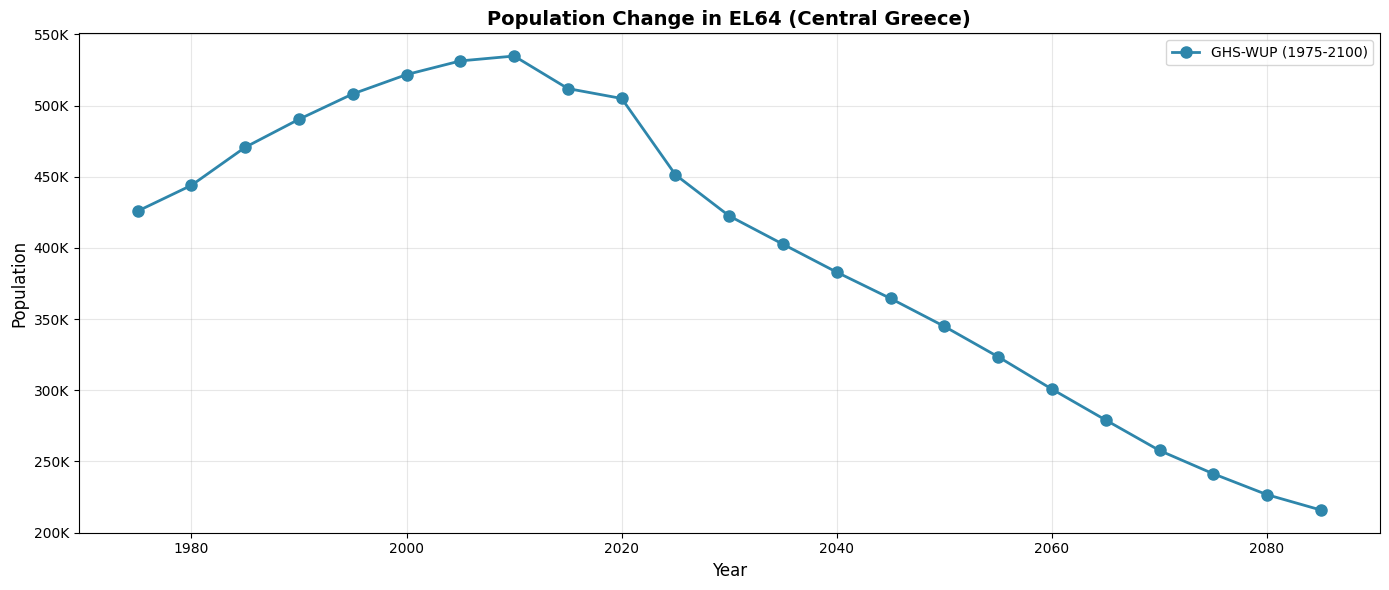

In [14]:
# Plot population timeseries
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_pop['year'], df_pop['population'], 
        marker='o', linewidth=2, markersize=8, label=f'{dataset_name} {year_range}', color='#2E86AB')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Population', fontsize=12)
ax.set_title(f'Population Change in {admin_id} (Central Greece)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Format y-axis to show numbers in thousands/millions
ax.ticklabel_format(style='plain', axis='y')
from matplotlib.ticker import FuncFormatter
def millions(x, pos):
    return f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'
ax.yaxis.set_major_formatter(FuncFormatter(millions))

plt.tight_layout()
plt.show()

In [15]:
# Summary statistics
first_year = df_pop['year'].iloc[0]
last_year = df_pop['year'].iloc[-1]

print(f"{dataset_name} Summary ({first_year:.0f}-{last_year:.0f}):")
print(f"  Initial population ({first_year:.0f}): {df_pop['population'].iloc[0]:,.0f}")
print(f"  Final population ({last_year:.0f}): {df_pop['population'].iloc[-1]:,.0f}")
print(f"  Change: {df_pop['population'].iloc[-1] - df_pop['population'].iloc[0]:+,.0f} ({((df_pop['population'].iloc[-1] / df_pop['population'].iloc[0]) - 1) * 100:+.1f}%)")
print(f"  Peak population: {df_pop['population'].max():,.0f} in {df_pop.loc[df_pop['population'].idxmax(), 'year']:.0f}")

GHS-WUP Summary (1975-2085):
  Initial population (1975): 425,902
  Final population (2085): 215,900
  Change: -210,002 (-49.3%)
  Peak population: 534,820 in 2010


## What's next?

You now have timeseries of population data that can be used as exposure in drought risk assessments. The CSV files are saved and ready to be used in other analyses.

## Comparison of population datasets

If you have run this notebook for both GHS-POP and GHS-WUP datasets, you can compare them here. This section will only work if both CSV files exist.

In [16]:
# Try to load both datasets for comparison
csv_file_ghs_pop = output_dir / f"population_ghs_pop_{admin_id}.csv"
csv_file_ghs_wup = output_dir / f"population_ghs_wup_{admin_id}.csv"

datasets_available = []
dfs = {}

if csv_file_ghs_pop.exists():
    dfs['GHS-POP'] = pd.read_csv(csv_file_ghs_pop)
    datasets_available.append('GHS-POP')
    print(f"✓ Loaded GHS-POP data: {len(dfs['GHS-POP'])} years")

if csv_file_ghs_wup.exists():
    dfs['GHS-WUP'] = pd.read_csv(csv_file_ghs_wup)
    datasets_available.append('GHS-WUP')
    print(f"✓ Loaded GHS-WUP data: {len(dfs['GHS-WUP'])} years")

if len(datasets_available) == 0:
    print("⚠ No CSV files found. Run the notebook for at least one dataset first.")
elif len(datasets_available) == 1:
    print(f"\n⚠ Only {datasets_available[0]} data available. Run the notebook with the other dataset to enable comparison.")
else:
    print(f"\n✓ Both datasets available for comparison!")

✓ Loaded GHS-POP data: 12 years
✓ Loaded GHS-WUP data: 23 years

✓ Both datasets available for comparison!


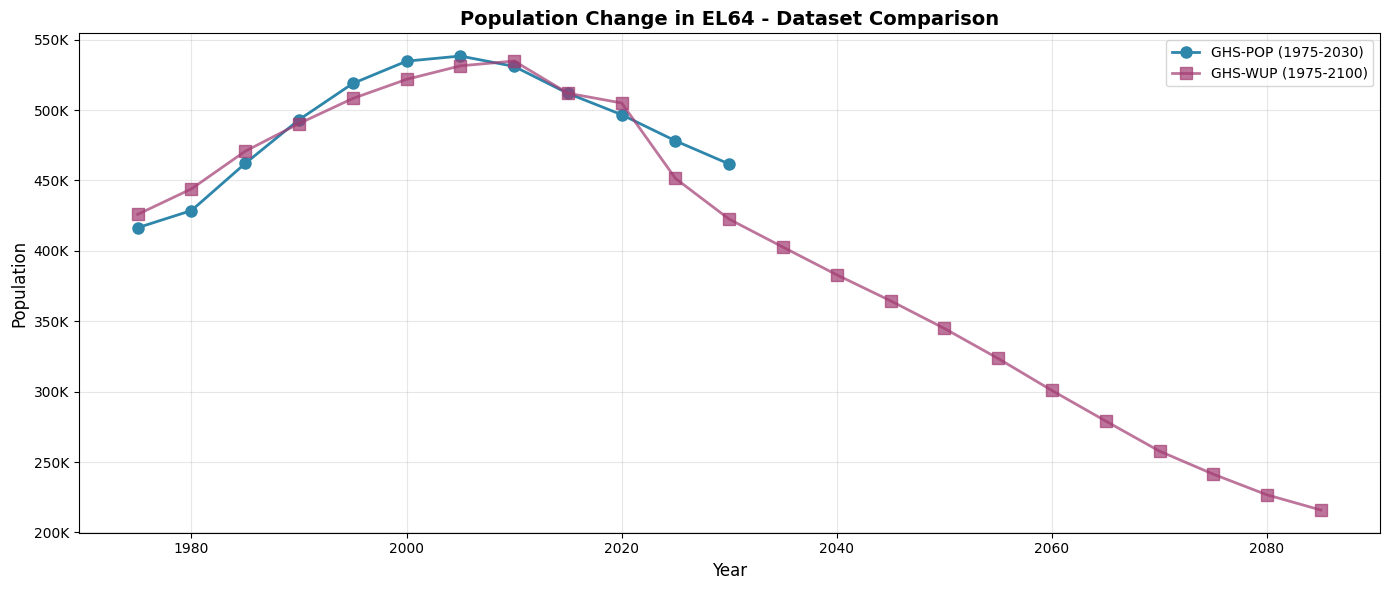

In [17]:
# Plot comparison if both datasets are available
if len(datasets_available) == 2:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    ax.plot(dfs['GHS-POP']['year'], dfs['GHS-POP']['population'], 
            marker='o', linewidth=2, markersize=8, label='GHS-POP (1975-2030)', color='#2E86AB')
    ax.plot(dfs['GHS-WUP']['year'], dfs['GHS-WUP']['population'], 
            marker='s', linewidth=2, markersize=8, label='GHS-WUP (1975-2100)', color='#A23B72', alpha=0.7)
    
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('Population', fontsize=12)
    ax.set_title(f'Population Change in {admin_id} - Dataset Comparison', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Format y-axis to show numbers in thousands/millions
    ax.ticklabel_format(style='plain', axis='y')
    from matplotlib.ticker import FuncFormatter
    def millions(x, pos):
        return f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'
    ax.yaxis.set_major_formatter(FuncFormatter(millions))
    
    plt.tight_layout()
    plt.show()

In [18]:
# Compare overlapping years (1975-2030)
if len(datasets_available) == 2:
    # Merge datasets on year for overlapping period
    df_comparison = dfs['GHS-POP'].merge(dfs['GHS-WUP'], on='year', suffixes=('_pop', '_wup'))
    
    # Calculate differences
    df_comparison['difference'] = df_comparison['population_wup'] - df_comparison['population_pop']
    df_comparison['percent_diff'] = (df_comparison['difference'] / df_comparison['population_pop']) * 100
    
    print("Comparison of GHS-POP vs GHS-WUP for overlapping years (1975-2030):")
    print("="*80)
    print(f"{'Year':<8} {'GHS-POP':>15} {'GHS-WUP':>15} {'Difference':>15} {'Diff %':>10}")
    print("-"*80)
    
    for _, row in df_comparison.iterrows():
        print(f"{row['year']:<8.0f} {row['population_pop']:>15,.0f} {row['population_wup']:>15,.0f} "
              f"{row['difference']:>15,.0f} {row['percent_diff']:>9.2f}%")
    
    print("\nSummary:")
    print(f"  Mean absolute difference: {df_comparison['difference'].abs().mean():,.0f}")
    print(f"  Mean percentage difference: {df_comparison['percent_diff'].abs().mean():.2f}%")
    print(f"  Max difference: {df_comparison['difference'].abs().max():,.0f} in {df_comparison.loc[df_comparison['difference'].abs().idxmax(), 'year']:.0f}")

Comparison of GHS-POP vs GHS-WUP for overlapping years (1975-2030):
Year             GHS-POP         GHS-WUP      Difference     Diff %
--------------------------------------------------------------------------------
1975             416,420         425,902           9,482      2.28%
1980             428,631         444,018          15,387      3.59%
1985             462,089         470,751           8,662      1.87%
1990             493,137         490,413          -2,724     -0.55%
1995             518,887         508,224         -10,662     -2.05%
2000             534,728         521,798         -12,930     -2.42%
2005             538,363         531,397          -6,966     -1.29%
2010             530,982         534,820           3,837      0.72%
2015             511,821         511,960             139      0.03%
2020             496,688         505,003           8,314      1.67%
2025             478,108         451,386         -26,722     -5.59%
2030             461,641         42